In [1]:
!pip install scikit-learn

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

# import dataset

In [3]:
data_df = pd.read_csv("./data.csv")

In [4]:
data_df.head()

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
4,Germany,40.0,NaN,Yes


### Data Imputation (Thay thế dữ liệu thiếu)

Các tập dữ liệu thường có giá trị bị thiếu và điều này có thể gây vấn đề cho các thuật toán Machine Learning.

Việc xác định và thay thế các giá trị thiếu trong từng cột của dataset trước khi xây dựng mô hình dự đoán là một thực hành tốt.

Phương pháp thay thế dữ liệu thiếu này được gọi là Data Imputation.

In [5]:
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Country    10 non-null     str    
 1   Age        9 non-null      float64
 2   Salary     9 non-null      float64
 3   Purchased  10 non-null     str    
dtypes: float64(2), str(2)
memory usage: 452.0 bytes


In [6]:
for col in data_df.columns:
    missing_data = data_df[col].isna().sum()
    missing_percent = missing_data/len(data_df)*100
    print(f"Column : {col}: has {missing_percent}% missing data")

Column : Country: has 0.0% missing data
Column : Age: has 10.0% missing data
Column : Salary: has 10.0% missing data
Column : Purchased: has 0.0% missing data


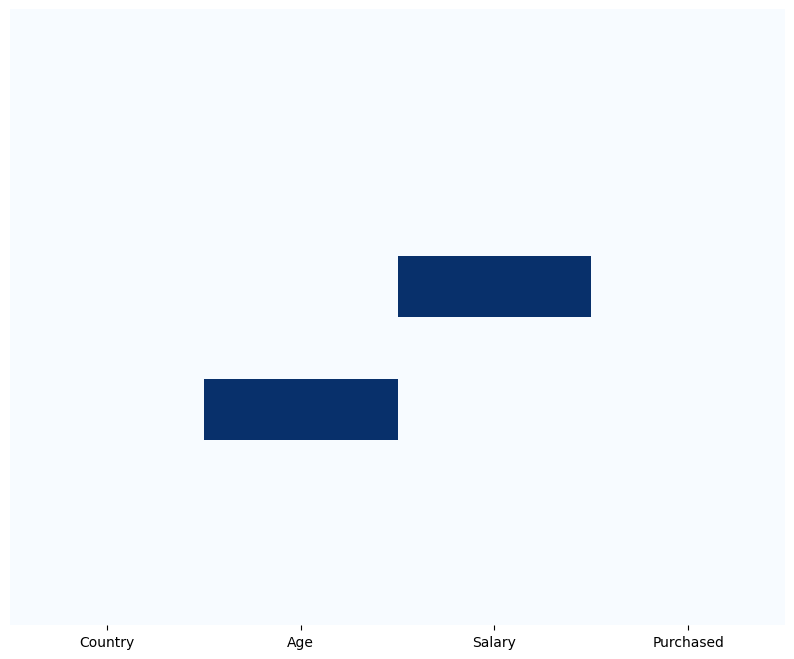

In [7]:
fig, ax =plt.subplots(figsize=(10,8))
sns.heatmap(data = data_df.isna(),cmap="Blues",cbar=False,yticklabels=False);

In [8]:
data_df.head()

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
4,Germany,40.0,NaN,Yes


In [9]:
x = data_df.iloc[:,:-1].values

In [10]:
x

array([['France', 44.0, 72000.0],
       ['Spain', 27.0, 48000.0],
       ['Germany', 30.0, 54000.0],
       ['Spain', 38.0, 61000.0],
       ['Germany', 40.0, nan],
       ['France', 35.0, 58000.0],
       ['Spain', nan, 52000.0],
       ['France', 48.0, 79000.0],
       ['Germany', 50.0, 83000.0],
       ['France', 37.0, 67000.0]], dtype=object)

In [11]:
y=data_df.iloc[:,-1].values

In [12]:
y

<StringArray>
['No', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes']
Length: 10, dtype: str

In [13]:
from sklearn.impute import SimpleImputer

In [14]:
# Tạo một đối tượng SimpleImputer:
# np.nan là giá trị bị thiếu trong dataset
# strategy="mean" nghĩa là thay thế bằng giá trị trung bình

imputer = SimpleImputer(missing_values=np.nan, strategy="mean")

imputer.fit(x[:, 1:3])
x[:, 1:3] = imputer.transform(x[:,1:3])

In [15]:
x

array([['France', 44.0, 72000.0],
       ['Spain', 27.0, 48000.0],
       ['Germany', 30.0, 54000.0],
       ['Spain', 38.0, 61000.0],
       ['Germany', 40.0, 63777.77777777778],
       ['France', 35.0, 58000.0],
       ['Spain', 38.77777777777778, 52000.0],
       ['France', 48.0, 79000.0],
       ['Germany', 50.0, 83000.0],
       ['France', 37.0, 67000.0]], dtype=object)

## Mã hóa dữ liệu phân loại

### Mã hóa biến độc lập (X)`

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(), [0])
    ],
    remainder="passthrough"
)

x=ct.fit_transform(x)

In [17]:
x

array([[1.0, 0.0, 0.0, 44.0, 72000.0],
       [0.0, 0.0, 1.0, 27.0, 48000.0],
       [0.0, 1.0, 0.0, 30.0, 54000.0],
       [0.0, 0.0, 1.0, 38.0, 61000.0],
       [0.0, 1.0, 0.0, 40.0, 63777.77777777778],
       [1.0, 0.0, 0.0, 35.0, 58000.0],
       [0.0, 0.0, 1.0, 38.77777777777778, 52000.0],
       [1.0, 0.0, 0.0, 48.0, 79000.0],
       [0.0, 1.0, 0.0, 50.0, 83000.0],
       [1.0, 0.0, 0.0, 37.0, 67000.0]], dtype=object)

### Mã hóa biến phụ thuộc (y)

In [18]:
y

<StringArray>
['No', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes']
Length: 10, dtype: str

In [19]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [20]:
y

array([0, 1, 0, 0, 1, 1, 0, 1, 0, 1])

## Chia dataset (X = dữ liệu, y = đầu ra) thành tập Training và Test

In [21]:
from sklearn.model_selection import train_test_split
np.random.seed(42)

x_train,x_test,y_train,y_test= train_test_split(x,y,test_size = 0.2)

In [22]:
x_train

array([[1.0, 0.0, 0.0, 35.0, 58000.0],
       [1.0, 0.0, 0.0, 44.0, 72000.0],
       [1.0, 0.0, 0.0, 48.0, 79000.0],
       [0.0, 1.0, 0.0, 30.0, 54000.0],
       [1.0, 0.0, 0.0, 37.0, 67000.0],
       [0.0, 1.0, 0.0, 40.0, 63777.77777777778],
       [0.0, 0.0, 1.0, 38.0, 61000.0],
       [0.0, 0.0, 1.0, 38.77777777777778, 52000.0]], dtype=object)

In [23]:
y_train

array([1, 0, 1, 0, 1, 1, 0, 0])

In [24]:
data_df

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
4,Germany,40.0,NaN,Yes
5,France,35.0,58000.0,Yes
6,Spain,NaN,52000.0,No
7,France,48.0,79000.0,Yes
8,Germany,50.0,83000.0,No
9,France,37.0,67000.0,Yes


In [25]:
x_test

array([[0.0, 1.0, 0.0, 50.0, 83000.0],
       [0.0, 0.0, 1.0, 27.0, 48000.0]], dtype=object)

In [26]:
y_test

array([0, 1])

In [27]:
data_df

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
4,Germany,40.0,NaN,Yes
5,France,35.0,58000.0,Yes
6,Spain,NaN,52000.0,No
7,France,48.0,79000.0,Yes
8,Germany,50.0,83000.0,No
9,France,37.0,67000.0,Yes


### Feature Scaling

Feature Scaling là quá trình chuẩn hóa phạm vi giá trị của các đặc trưng trong dataset.

In [31]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

x_train[:, 3:] = sc.fit_transform(x_train[:, 3:])

In [32]:
x_train

array([[ 1.        ,  0.        ,  0.        , -0.7529426 , -0.62603778],
       [ 1.        ,  0.        ,  0.        ,  1.00845381,  1.01304295],
       [ 1.        ,  0.        ,  0.        ,  1.79129666,  1.83258331],
       [ 0.        ,  1.        ,  0.        , -1.73149616, -1.09434656],
       [ 1.        ,  0.        ,  0.        , -0.36152118,  0.42765698],
       [ 0.        ,  1.        ,  0.        ,  0.22561096,  0.05040824],
       [ 0.        ,  0.        ,  1.        , -0.16581046, -0.27480619],
       [ 0.        ,  0.        ,  1.        , -0.01359102, -1.32850095]])

In [33]:
x_test[:, 3:] = sc.transform(x_test[:,3:])

In [34]:
x_test

array([[0.0e+00, 1.0e+00, 0.0e+00, 5.0e+01, 8.3e+04],
       [0.0e+00, 0.0e+00, 1.0e+00, 2.7e+01, 4.8e+04]])